In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

import joblib

c:\Users\deeks\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop("CustomerID", axis=1, inplace=True)

In [9]:
X = df[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
]

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
aic_scores = []
bic_scores = []

for n in range(1, 11):

    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X_scaled)

    aic_scores.append(
        gmm.aic(X_scaled)
    )

    bic_scores.append(
        gmm.bic(X_scaled)
    )

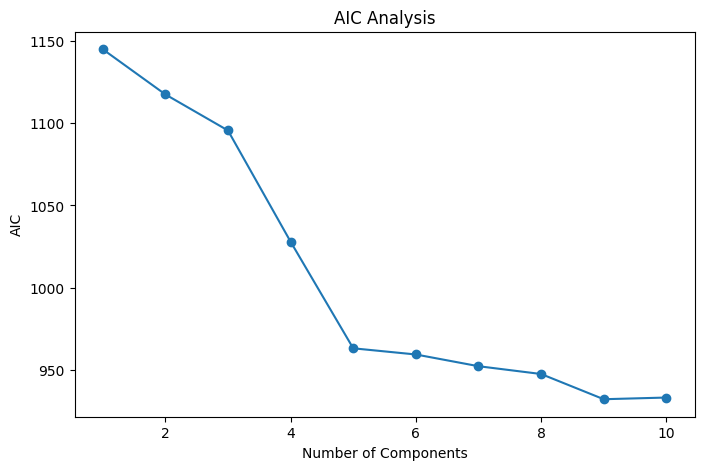

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    aic_scores,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("AIC")
plt.title("AIC Analysis")

plt.show()

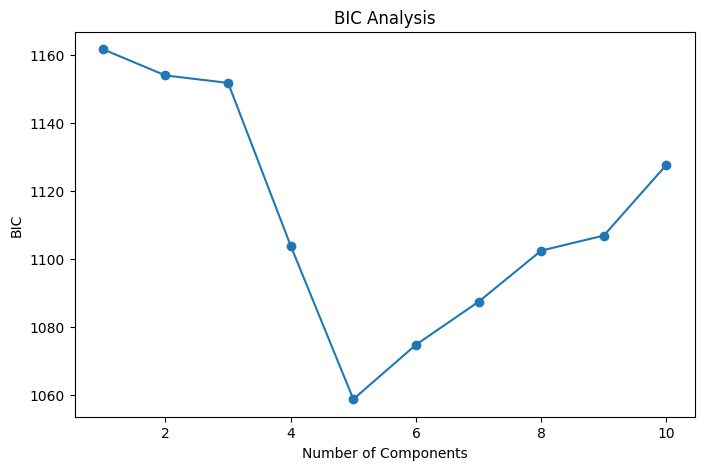

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    bic_scores,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC Analysis")

plt.show()

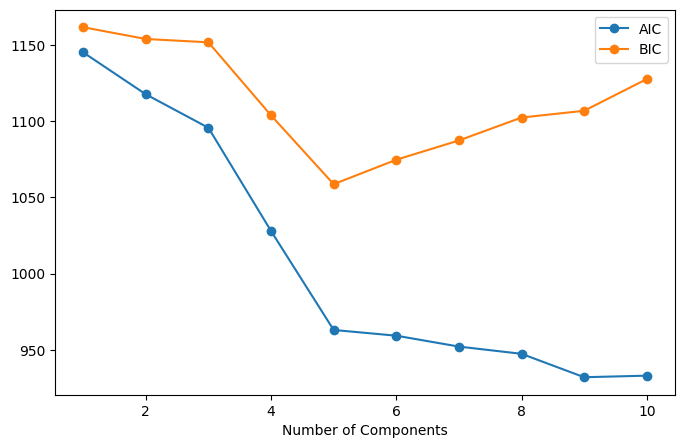

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    aic_scores,
    marker='o',
    label='AIC'
)

plt.plot(
    range(1,11),
    bic_scores,
    marker='o',
    label='BIC'
)

plt.legend()

plt.xlabel("Number of Components")

plt.show()

In [15]:
gmm = GaussianMixture(
    n_components=5,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [16]:
clusters = gmm.predict(
    X_scaled
)

In [17]:
df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


In [18]:
sil_score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.5536892843811245


In [19]:
db_score = davies_bouldin_score(
    X_scaled,
    clusters
)

print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 0.5760100302410824


In [20]:
df["Cluster"].value_counts().sort_index()

Cluster
0    84
1    39
2    21
3    33
4    23
Name: count, dtype: int64

In [21]:
cluster_summary = df.groupby("Cluster")[
    ["Annual Income (k$)",
     "Spending Score (1-100)"]
].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.642857,49.369048
1,86.538462,82.128205
2,25.095238,80.047619
3,88.818182,16.000000
4,26.304348,20.913043


In [22]:
centers = scaler.inverse_transform(
    gmm.means_
)

centers_df = pd.DataFrame(
    centers,
    columns=X.columns
)

centers_df

,Annual Income (k$),Spending Score (1-100)
0,55.710354,49.406987
1,86.240633,82.020375
2,25.117486,80.128174
3,88.813008,16.124618
4,27.031152,22.166702


In [23]:
probabilities = gmm.predict_proba(
    X_scaled[:5]
)

probabilities

array([[1.57689698e-05, 1.88009163e-08, 9.52031247e-04, 5.20013085e-08,
        9.99032129e-01],
       [1.62776204e-05, 1.89596786e-04, 9.99790184e-01, 4.21013390e-23,
        3.94154449e-06],
       [2.21339374e-19, 9.52615737e-19, 1.22549539e-12, 1.86223280e-04,
        9.99813777e-01],
       [1.05444778e-04, 1.80087695e-04, 9.99693745e-01, 3.79390067e-21,
        2.07229768e-05],
       [6.47301428e-05, 3.84273231e-08, 1.55669540e-03, 4.75722704e-08,
        9.98378488e-01]])

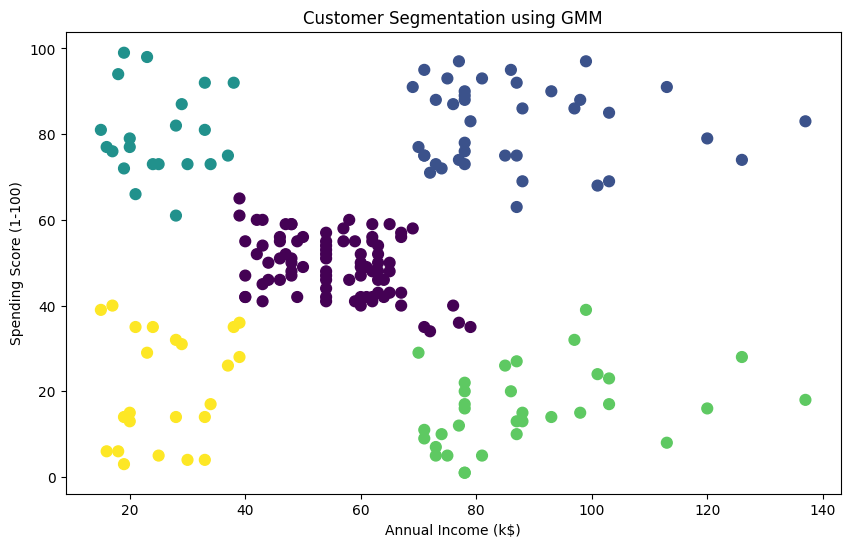

In [24]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using GMM")

plt.show()

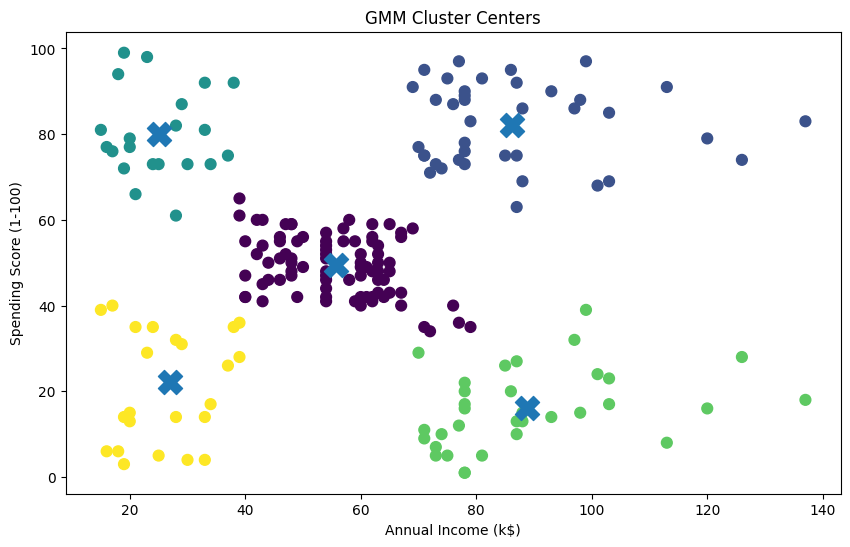

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=300
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("GMM Cluster Centers")

plt.show()

In [26]:
joblib.dump(
    gmm,
    "models/gmm_model.pkl"
)

['models/gmm_model.pkl']

In [27]:
joblib.dump(
    scaler,
    "models/gmm_scaler.pkl"
)

['models/gmm_scaler.pkl']

In [28]:
customer = pd.DataFrame(
    [[80,90]],
    columns=[
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

customer_scaled = scaler.transform(
    customer
)

cluster = gmm.predict(
    customer_scaled
)[0]

print("Cluster:", cluster)

Cluster: 1


In [29]:
probs = gmm.predict_proba(
    customer_scaled
)

print(probs)

[[2.31047830e-13 1.00000000e+00 8.26142141e-14 2.02675449e-17
  4.40981957e-12]]
